In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df=pd.read_csv("heart.csv")
print(df.head())
print(df.info())
print(df.describe())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    0   0       188   266    0        0      106      0      4.2      2   
1   30    0   1       123   384    0        2      121      1      1.4      2   
2   39    1   2       129   205    0        1       97      0      2.4      1   
3   31    1   0       142   166    0        2      163      0      4.4      0   
4   43    0   3       129   358    0        0      165      1      1.3      1   

   ca  thal  target  
0   0     3       1  
1   2     1       1  
2   2     3       0  
3   1     2       1  
4   0     3       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5 

In [12]:
print(df['target'].value_counts())

target
1    243
0     60
Name: count, dtype: int64


In [28]:
import pandas as pd
df=pd.read_csv("heart.csv")
print(df.shape)
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicaties:", df.duplicated().sum())

print("\nData types:", df.dtypes)

print("\nAge:",df['age'].min(), "-", df['age'].max())
print("Cholesterol:", df['chol'].min(), "-", df['chol'].max())
print("Blood Pressure:", df['trestbps'].min(), "-", df['trestbps'].max())


(303, 14)
Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicaties: 0

Data types: age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Age: 29 - 77
Cholesterol: 126 - 564
Blood Pressure: 94 - 200


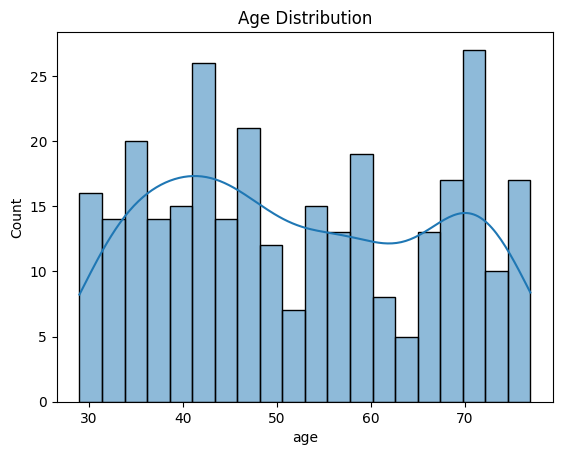

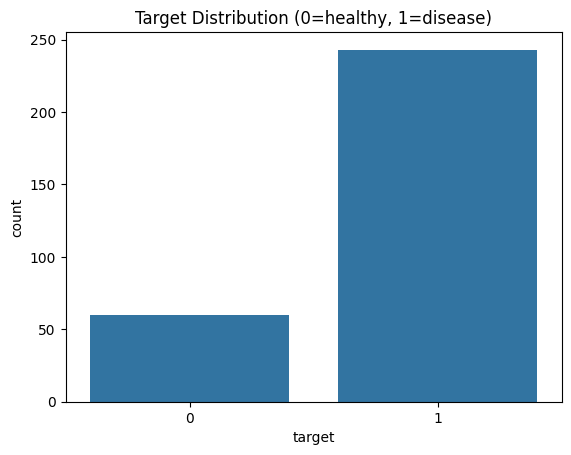

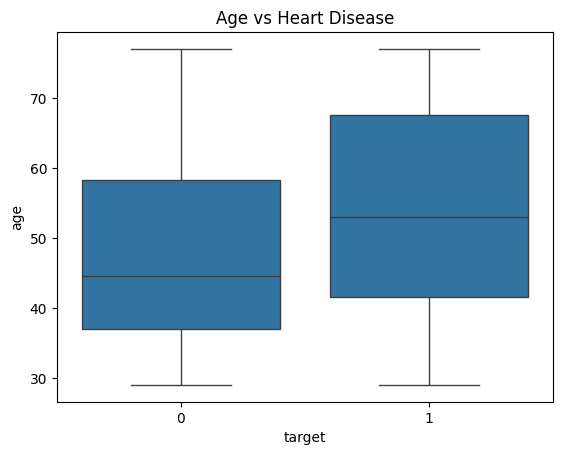

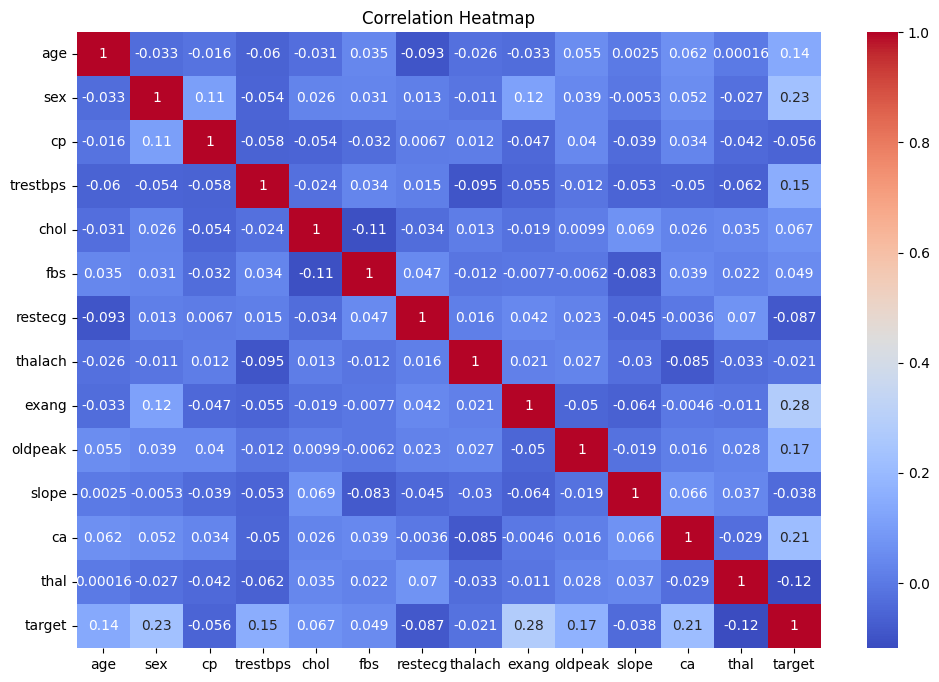

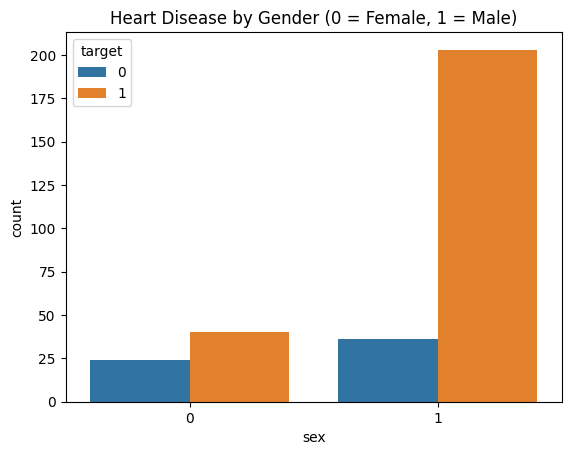

In [14]:
import seaborn as sns 
import matplotlib.pyplot as plt
df=pd.read_csv('heart.csv')
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

sns.countplot(x='target', data=df)
plt.title("Target Distribution (0=healthy, 1=disease)")
plt.show()

sns.boxplot(x='target', y='age', data=df)
plt.title('Age vs Heart Disease')
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.countplot(x='sex', hue='target', data=df)
plt.title("Heart Disease by Gender (0 = Female, 1 = Male)")
plt.show()

target      1.000000
exang       0.283242
sex         0.229816
ca          0.211231
oldpeak     0.170817
trestbps    0.154236
age         0.141703
chol        0.067121
fbs         0.048726
thalach    -0.020556
slope      -0.037911
cp         -0.056195
restecg    -0.087115
thal       -0.118457
Name: target, dtype: float64


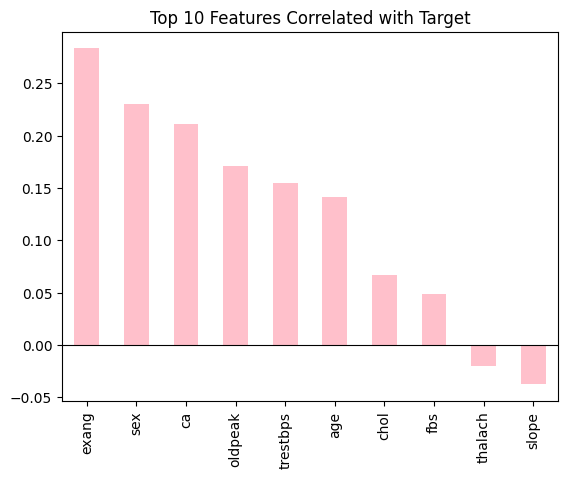

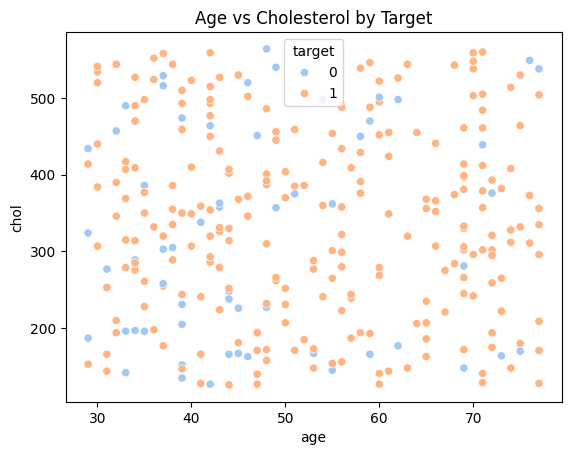

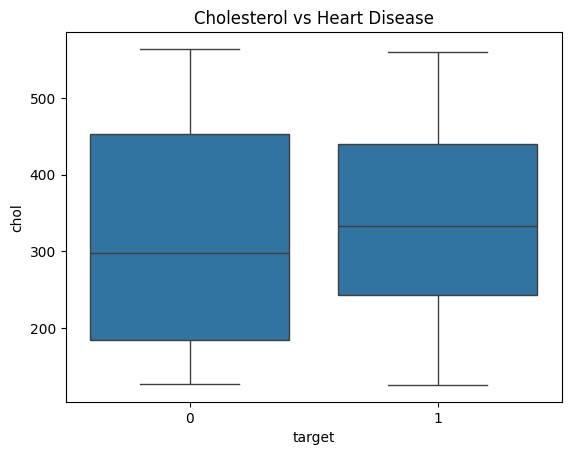

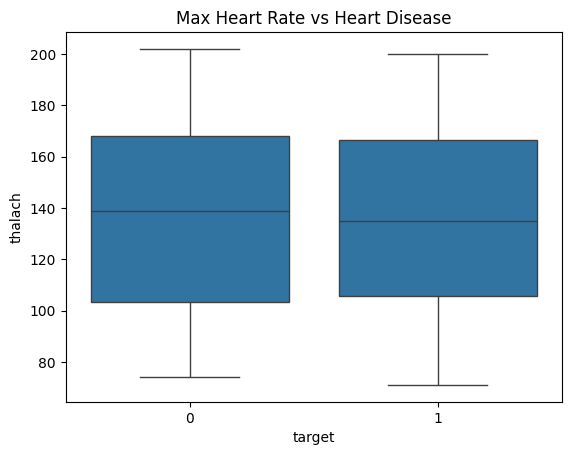

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('heart.csv')
correlations=df.corr(numeric_only=True)['target'].sort_values(ascending=False)
print(correlations)

correlations.drop('target').head(10).plot(kind='bar', color='pink')
plt.title("Top 10 Features Correlated with Target")
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

sns.scatterplot(x='age', y='chol', hue='target', data=df, palette='pastel')
plt.title("Age vs Cholesterol by Target")
plt.show()

sns.boxplot(x='target', y='chol', data=df)
plt.title("Cholesterol vs Heart Disease")
plt.show()

sns.boxplot(x='target', y='thalach', data=df)
plt.title("Max Heart Rate vs Heart Disease")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

x=df.drop('target', axis=1)
y=df['target']

x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)

model=RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

y_pred=model.predict(x_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7704918032786885
              precision    recall  f1-score   support

           0       1.00      0.18      0.30        17
           1       0.76      1.00      0.86        44

    accuracy                           0.77        61
   macro avg       0.88      0.59      0.58        61
weighted avg       0.83      0.77      0.71        61



Accuracy: 0.7540983606557377
              precision    recall  f1-score   support

           0       1.00      0.12      0.21        17
           1       0.75      1.00      0.85        44

    accuracy                           0.75        61
   macro avg       0.87      0.56      0.53        61
weighted avg       0.82      0.75      0.67        61



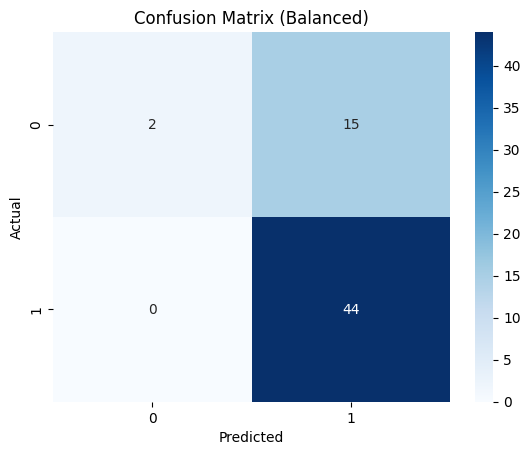

In [19]:
model_balanced=RandomForestClassifier(random_state=42, class_weight='balanced')
model_balanced.fit(x_train, y_train)

y_pred_balanced=model_balanced.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

sns.heatmap(confusion_matrix(y_test, y_pred_balanced), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Balanced)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Before SMOTE: {1: 199, 0: 43}
After SMOTE: {1: 199, 0: 199}
Accuracy: 0.8032786885245902
              precision    recall  f1-score   support

           0       0.73      0.47      0.57        17
           1       0.82      0.93      0.87        44

    accuracy                           0.80        61
   macro avg       0.77      0.70      0.72        61
weighted avg       0.79      0.80      0.79        61



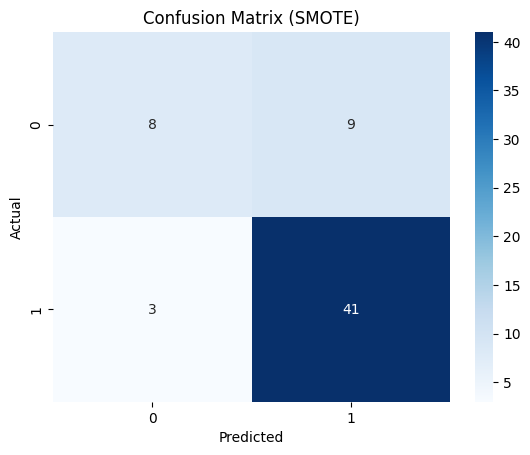

In [22]:
!pip install imbalanced-learn 

from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_smote, y_train_smote=smote.fit_resample(x_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

model_smote=RandomForestClassifier(random_state=42)
model_smote.fit(x_train_smote, y_train_smote)

y_pred_smote=model_smote.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

sns.heatmap(confusion_matrix(y_test, y_pred_smote), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

exang       0.177398
oldpeak     0.148762
trestbps    0.120508
chol        0.091189
ca          0.086880
age         0.081592
thalach     0.075122
cp          0.056578
sex         0.047265
slope       0.039618
thal        0.028917
restecg     0.027073
fbs         0.019097
dtype: float64


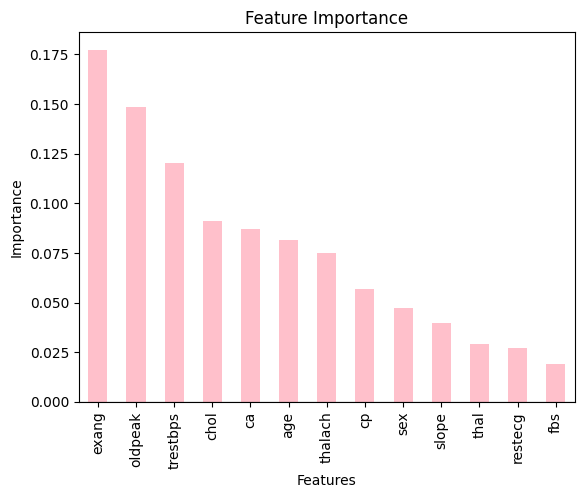

In [27]:
importances=pd.Series(model_smote.feature_importances_, index=x.columns).sort_values(ascending=False)
print(importances)
importances.plot(kind='bar', color='pink')
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()